# 🫁 Lung Cancer Classification Metrics

This notebook trains a **Logistic Regression** model on the Kaggle Survey Lung Cancer dataset and evaluates it using the 4 core classification metrics:
- **Accuracy**
- **Precision**
- **Recall**
- **F1 Score**

## Step 1: Import Libraries

In [1]:
import io
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load & Explore the Lung Cancer Dataset
*(Reads local `lung_cancer_data.csv` file)*

In [2]:
# Load dataset
df = pd.read_csv('lung_cancer_data.csv')
print(f"✅ Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

✅ Dataset Loaded: 289 rows, 16 columns


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


## Step 3: Feature Preprocessing & Encoding
- **GENDER**: Encode `M` → 1, `F` → 0
- **LUNG_CANCER**: Encode `YES` → 1, `NO` → 0
- **Symptom / Habit Columns**: Convert `2` (Yes) → 1, `1` (No) → 0

In [3]:
# Encode Gender & Target
df['GENDER'] = df['GENDER'].map({'M': 1, 'F': 0})
df['LUNG_CANCER'] = df['LUNG_CANCER'].map({'YES': 1, 'NO': 0})

# Convert 1/2 binary feature values to 0/1
binary_cols = ['SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE',
               'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
               'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
               'SWALLOWING_DIFFICULTY', 'CHEST_PAIN']

for col in binary_cols:
    if df[col].max() == 2:
        df[col] = df[col].map({2: 1, 1: 0})

print("✅ Encoding completed!")
df.head()

✅ Encoding completed!


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


## Step 4: Train-Test Split & Logistic Regression Training

In [4]:
# Separate features (X) and target (y)
X = df.drop('LUNG_CANCER', axis=1)
y = df['LUNG_CANCER']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train Model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
print("✅ Logistic Regression model trained successfully!")

Training samples: 231


Testing samples:  58
✅ Logistic Regression model trained successfully!


---
## Step 5: Calculate Classification Metrics

### 📌 Explanation of the 4 Key Topics:

1. **Accuracy**: Overall proportion of correctly predicted instances across all classes.
   $$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

2. **Precision**: Measure of exactness — out of all positive predictions, how many were actually positive?
   $$\text{Precision} = \frac{TP}{TP + FP}$$

3. **Recall (Sensitivity)**: Measure of completeness — out of all actual positive cases, how many did the model capture?
   $$\text{Recall} = \frac{TP}{TP + FN}$$

4. **F1 Score**: Harmonic mean of Precision and Recall, balancing both metrics into a single score.
   $$\text{F1 Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [5]:
# Calculate evaluation metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)

print("=" * 55)
print("   📊 LUNG CANCER CLASSIFICATION METRICS")
print("=" * 55)
print(f"   📌 Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"   📌 Precision : {precision:.4f}  ({precision*100:.2f}%)")
print(f"   📌 Recall    : {recall:.4f}  ({recall*100:.2f}%)")
print(f"   📌 F1 Score  : {f1:.4f}  ({f1*100:.2f}%)")
print("=" * 55)

   📊 LUNG CANCER CLASSIFICATION METRICS
   📌 Accuracy  : 0.9483  (94.83%)
   📌 Precision : 0.9636  (96.36%)
   📌 Recall    : 0.9815  (98.15%)
   📌 F1 Score  : 0.9725  (97.25%)


## Step 6: Confusion Matrix & Breakdown

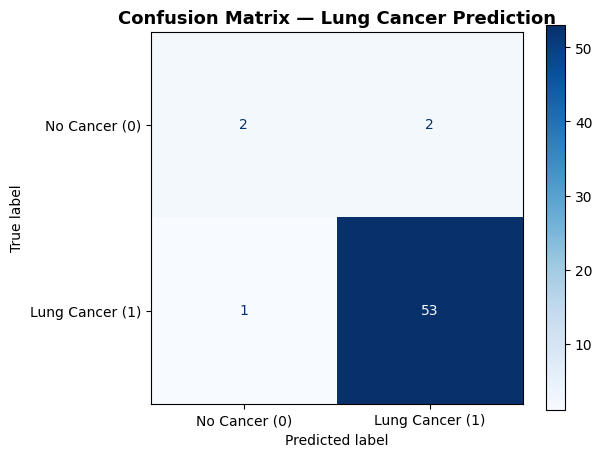

True Negatives  (TN) = 2
False Positives (FP) = 2
False Negatives (FN) = 1
True Positives  (TP) = 53


In [6]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Cancer (0)', 'Lung Cancer (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Confusion Matrix — Lung Cancer Prediction', fontsize=13, fontweight='bold')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN) = {tn}")
print(f"False Positives (FP) = {fp}")
print(f"False Negatives (FN) = {fn}")
print(f"True Positives  (TP) = {tp}")

## Step 7: Classification Report

In [7]:
# Detailed Classification Report
print(classification_report(y_test, y_pred, target_names=['No Cancer (0)', 'Lung Cancer (1)']))

                 precision    recall  f1-score   support

  No Cancer (0)       0.67      0.50      0.57         4
Lung Cancer (1)       0.96      0.98      0.97        54

       accuracy                           0.95        58
      macro avg       0.82      0.74      0.77        58
   weighted avg       0.94      0.95      0.94        58



## Step 8: Visual Metrics Comparison Bar Chart

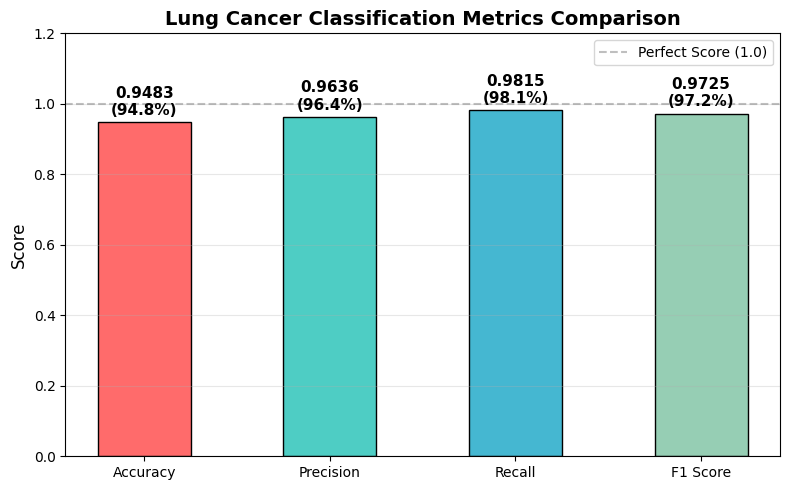

In [8]:
# Bar chart comparison of all 4 metrics
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metric_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

plt.figure(figsize=(8, 5))
bars = plt.bar(metric_names, metric_values, color=colors, edgecolor='black', width=0.5)

for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.4f}\n({val*100:.1f}%)', ha='center', fontweight='bold', fontsize=11)

plt.ylim(0, 1.2)
plt.ylabel('Score', fontsize=12)
plt.title('Lung Cancer Classification Metrics Comparison', fontsize=14, fontweight='bold')
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5, label='Perfect Score (1.0)')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()